# <b><font color='skyblue'>Практикум - Статистика, визуализация</font></b>

In [18]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

### <b><font color='skyblue'>Анализ удовлетворённости клиентов онлайн-магазина</font></b>

#### <b><font color='skyblue'>Описание датасета</font></b>
База данных международнай компании электронной коммерции. <br>
Поля
- <b>ID</b>: Идентификационный номер клиента.
- <b>Warehouse_block</b>: Компания имеет большой склад, который разделен на блоки, такие как A, B, C, D, E.
- <b>Mode_of_Shipment</b>: Компания осуществляет доставку продукции несколькими способами, такими как морской, авиа и наземный транспорт.
- <b>Customer_care_calls</b>: количество звонков, сделанных по вопросам, касающимся отправки груза.
- <b>Customer_rating</b>: Компания получила оценку от каждого клиента. 1 — самая низкая (худшая), 5 — самая высокая (лучшая).
- <b>Cost_of_the_Product</b>: Стоимость продукта в долларах США.
- <b>Prior_purchases</b>: Количество предыдущих покупок.
- <b>Product_importance</b>: компания классифицировала продукт по различным параметрам, таким как низкая, средняя, высокая.
- <b>Gender</b>: мужской и женский
- <b>Discount_offered</b>: скидка, предлагаемая на данный конкретный продукт.
- <b>Weight_in_gms</b>: Вес в граммах.
- <b>Reached.on.Time_Y.N</b>: это целевая переменная, где 1 указывает на то, что продукт НЕ был достигнут вовремя, а 0 указывает на то, что он был достигнут вовремя.

##### <b><font color='skyblue'>1. Загрузка данных</font></b>

In [6]:
# Загрузите данные из файла Ecommerce Customers.csv  в переменную df
df_customers = pd.read_csv('..//data//Ecommerce Customers.csv')
df_customers 

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [7]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [9]:
df_customers.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


##### <b><font color='skyblue'>2. Базовый анализ данных (меры центральной тенденции и разброса)</font></b>
- Рассчитайте среднее, медиану, моду и стандартное отклонение для веса, стоимости, скидки и рейтинга товаров.
- Интерпретируйте результаты.

In [10]:
Weight_in_gms_mean = df_customers['Weight_in_gms'].mean()
Weight_in_gms_median = df_customers['Weight_in_gms'].median()
Weight_in_gms_mode = df_customers['Weight_in_gms'].mode()[0]
Weight_in_gms_std = df_customers['Weight_in_gms'].std()
print(f"Weight in gms Mean: {Weight_in_gms_mean}")
print(f"Weight in gms Median: {Weight_in_gms_median}")
print(f"Weight in gms Mode: {Weight_in_gms_mode}")
print(f"Weight in gms Standard Deviation: {Weight_in_gms_std}")



Weight in gms Mean: 3634.016728793527
Weight in gms Median: 4149.0
Weight in gms Mode: 4883
Weight in gms Standard Deviation: 1635.3772514018872


In [11]:
Cost_of_the_Product_mean = df_customers['Cost_of_the_Product'].mean()
Cost_of_the_Product_median = df_customers['Cost_of_the_Product'].median()
Cost_of_the_Product_mode = df_customers['Cost_of_the_Product'].mode()[0]
Cost_of_the_Product_std = df_customers['Cost_of_the_Product'].std()
print(f"Cost of the Product Mean: {Cost_of_the_Product_mean}")
print(f"Cost of the Product Median: {Cost_of_the_Product_median}")
print(f"Cost of the Product Mode: {Cost_of_the_Product_mode}")
print(f"Cost of the Product Standard Deviation: {Cost_of_the_Product_std}")


Cost of the Product Mean: 210.19683607600692
Cost of the Product Median: 214.0
Cost of the Product Mode: 245
Cost of the Product Standard Deviation: 48.06327175153259


In [12]:
Discount_offered_mean = df_customers['Discount_offered'].mean()
Discount_offered_median = df_customers['Discount_offered'].median()
Discount_offered_mode = df_customers['Discount_offered'].mode()[0]
Discount_offered_std = df_customers['Discount_offered'].std()
print(f"Discount Offered Mean: {Discount_offered_mean}")
print(f"Discount Offered Median: {Discount_offered_median}")
print(f"Discount Offered Mode: {Discount_offered_mode}")
print(f"Discount Offered Standard Deviation: {Discount_offered_std}")


Discount Offered Mean: 13.37321574688608
Discount Offered Median: 7.0
Discount Offered Mode: 10
Discount Offered Standard Deviation: 16.205527080640096


In [13]:
Customer_rating_mean = df_customers['Customer_rating'].mean()
Customer_rating_median = df_customers['Customer_rating'].median()
Customer_rating_mode = df_customers['Customer_rating'].mode()[0]
Customer_rating_std = df_customers['Customer_rating'].std()
print(f"Customer Rating Mean: {Customer_rating_mean}")
print(f"Customer Rating Median: {Customer_rating_median}")
print(f"Customer Rating Mode: {Customer_rating_mode}")
print(f"Customer Rating Standard Deviation: {Customer_rating_std}")

Customer Rating Mean: 2.9905445949631786
Customer Rating Median: 3.0
Customer Rating Mode: 3
Customer Rating Standard Deviation: 1.4136031713232975


##### <b><font color='skyblue'>3. Проверка гипотез</font></b>
Проверьте гипотезу:
- H₀: Средний уровень удовлетворённости не отличается между мужчинами и женщинами.
- H₁: Средний уровень удовлетворённости отличается.

In [19]:
# - H₀: Средний уровень удовлетворённости не отличается между мужчинами и женщинами.
# - H₁: Средний уровень удовлетворённости отличается.
Customer_rating_male = df_customers[df_customers['Gender'] == 'M']['Customer_rating']
Customer_rating_female = df_customers[df_customers['Gender'] == 'F']['Customer_rating']
print(f"Средний уровень удовлетворённости мужчин: {Customer_rating_male.mean()}")
print(f"Средний уровень удовлетворённости женщин: {Customer_rating_female.mean()}")


t_stat, p_value = stats.ttest_ind(Customer_rating_male, Customer_rating_female, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
if p_value < 0.05:
    print("Существует статистически значимая разница в среднем уровне удовлетворённости между мужчинами и женщинами.")
else:
    print("Нет статистически значимой разницы в среднем уровне удовлетворённости между мужчинами и женщинами.")

Средний уровень удовлетворённости мужчин: 2.9944994499449944
Средний уровень удовлетворённости женщин: 2.986654643823264
T-statistic: 0.2909952645127288, P-value: 0.7710604298086761
Нет статистически значимой разницы в среднем уровне удовлетворённости между мужчинами и женщинами.


##### <b><font color='skyblue'>4. Доверительный интервал</font></b>
Постройте 95%-й доверительный интервал для среднего значения рейтинга товаров.

In [ ]:
mean_age = df_customers['Customer_rating'].mean()
sem_age = df_customers['Customer_rating'].sem()
# 2. Определите ДИ
confidence = 0.95
# 3. Вычислите ДИ
ci = stats.t.interval(confidence = confidence, 
                   df = len(df_customers) - 1, 
                   loc = mean_age, 
                   scale = sem_age)
# для больших выборок или с известным 𝜎:
# st.norm.interval(confidence = confidence, df = len(data)-1, loc = mean, scale = sem)
print(f"95% Доверительный интервал для среднего уровня удовлетворённости: {ci}")

95% Доверительный интервал для среднего уровня удовлетворённости: (np.float64(2.964123744148295), np.float64(3.0169654457780624))


##### <b><font color='skyblue'>5. Визуализация данных</font></b>
Постройте:
- Boxplot для Customer_rating в разрезе качества товара — для визуального сравнения распределений.
- Scatter plot между Product_importance и Customer_rating — для анализа зависимости.
- Pie chart для того, чтобы увидеть, сколько товаров было доставлено вовремя/не вовремя.

In [25]:
df_v = df_customers[['Customer_rating', 'Product_importance']]
df_v

,Customer_rating,Product_importance
0,2,low
1,5,low
2,2,low
3,3,medium
4,2,medium
...,...,...
10994,1,medium
10995,1,medium
10996,4,low
10997,2,medium


Средний рейтинг для низкой важности продукта: 2.98357560883519
Средний рейтинг для высокой важности продукта: 2.9936708860759493
Средний рейтинг для средней важности продукта: 2.9976861590239796


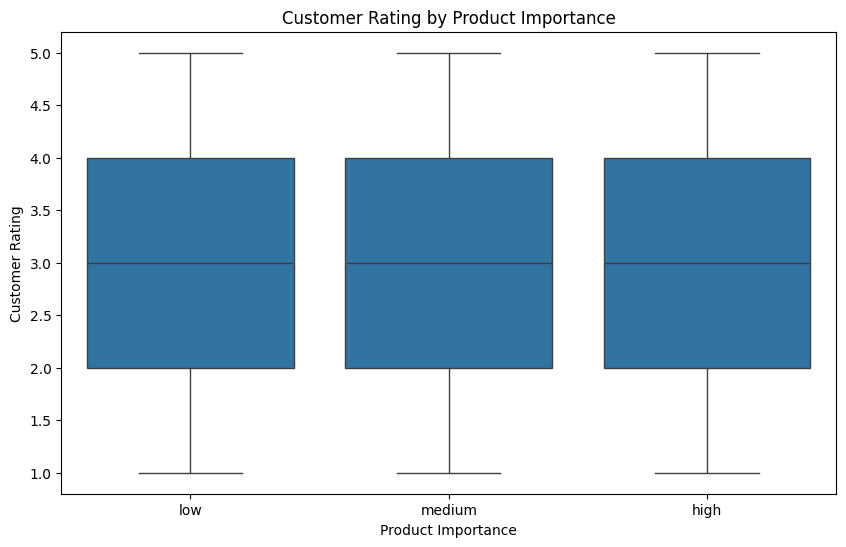

In [31]:
import seaborn as sns
rating_low = df_v[df_v['Product_importance'] == 'low']['Customer_rating'].mean()
rating_high = df_v[df_v['Product_importance'] == 'high']['Customer_rating'].mean()
rating_medium = df_v[df_v['Product_importance'] == 'medium']['Customer_rating'].mean()
print(f"Средний рейтинг для низкой важности продукта: {rating_low}")
print(f"Средний рейтинг для высокой важности продукта: {rating_high}")
print(f"Средний рейтинг для средней важности продукта: {rating_medium}")


plt.figure(figsize=(10, 6))
sns.boxplot(y = 'Customer_rating', x = 'Product_importance', data = df_v)
plt.xlabel('Product Importance')
plt.ylabel('Customer Rating')
plt.title('Customer Rating by Product Importance')
plt.show()

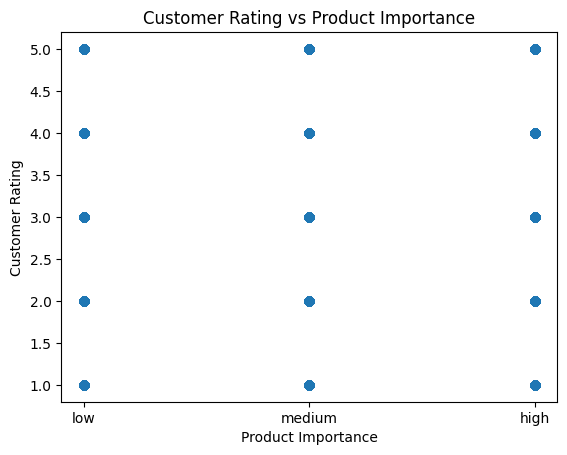

In [26]:
plt.scatter(df_v['Product_importance'], df_v['Customer_rating'])
plt.xlabel('Product Importance')
plt.ylabel('Customer Rating')
plt.title('Customer Rating vs Product Importance')
plt.show()

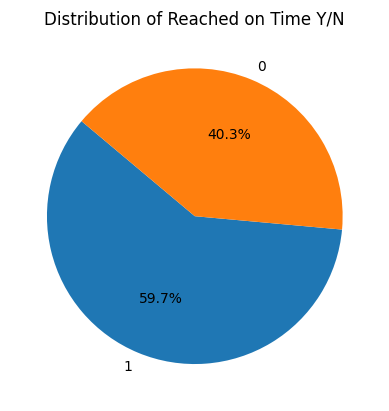

In [32]:
counts = df_customers['Reached.on.Time_Y.N'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Reached on Time Y/N')
plt.show()